# 01 — Data Exploration

This notebook explores the three credit datasets used in the benchmark:
- **Give Me Some Credit** (150K rows, Kaggle)
- **German Credit** (1K rows, UCI)
- **Taiwan Credit Default** (30K rows, UCI)

We examine class imbalance, missing values, feature distributions, and correlations.

In [1]:
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_credit_dataset, get_dataset_info

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Setup complete.')

Setup complete.


## 1. Load All Datasets

In [2]:
dataset_names = ['german_credit', 'taiwan_credit', 'give_me_credit']
datasets = {}

for name in dataset_names:
    X_train, X_test, y_train, y_test = load_credit_dataset(name)
    X_full = pd.concat([X_train, X_test], ignore_index=True)
    y_full = pd.concat([y_train, y_test], ignore_index=True)
    datasets[name] = (X_full, y_full)
    info = get_dataset_info(name)
    print(f"{name:20s}: {len(X_full):>8,} rows x {X_full.shape[1]:>3} features  "
          f"pos_rate={y_full.mean():.3f}  missing={X_full.isna().any().any()}")

german_credit       :    1,000 rows x  20 features  pos_rate=0.300  missing=False
taiwan_credit       :   30,000 rows x  23 features  pos_rate=0.221  missing=False
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
⚠️  Could not download from Kaggle: name 'exit' is not defined
   Generating synthetic credit data for testing...
give_me_credit      :  150,000 rows x  10 features  pos_rate=0.069  missing=True


## 2. Dataset Metadata

In [3]:
rows = []
for name in dataset_names:
    info = get_dataset_info(name)
    X, y = datasets[name]
    rows.append({
        'Dataset': info.get('display_name', name),
        'Rows': f"{len(X):,}",
        'Features': X.shape[1],
        'Positive Rate': f"{y.mean():.1%}",
        'Missing Values': X.isna().sum().sum(),
        'Categorical Cols': X.select_dtypes(include=['object','category']).shape[1],
        'Source': info.get('source', 'N/A'),
    })
pd.DataFrame(rows).set_index('Dataset')

,Rows,Features,Positive Rate,Missing Values,Categorical Cols,Source
Dataset,,,,,,
german_credit,"1,000",20,30.0%,0,13,UCI
taiwan_credit,"30,000",23,22.1%,0,0,UCI
give_me_credit,"150,000",10,6.9%,33848,0,Kaggle


## 3. Target Distribution (Class Imbalance)

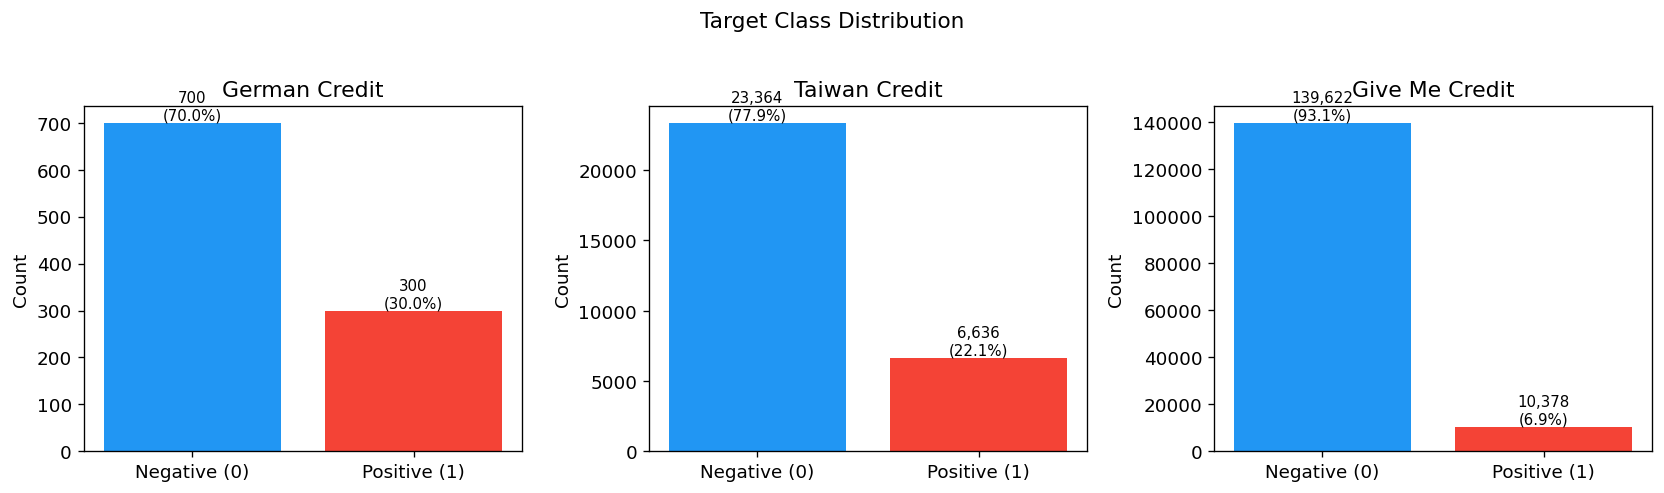

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#2196F3', '#F44336']

for ax, name in zip(axes, dataset_names):
    _, y = datasets[name]
    counts = y.value_counts().sort_index()
    ax.bar(['Negative (0)', 'Positive (1)'], counts.values, color=colors)
    ax.set_title(name.replace('_', ' ').title())
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts)*0.01, f'{v:,}\n({v/len(y):.1%})',
                ha='center', fontsize=9)

plt.suptitle('Target Class Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/01_class_distribution.png', bbox_inches='tight')
plt.show()

## 4. Missing Value Heatmaps


give_me_credit — columns with missing values:
MonthlyIncome    19.980667
NumDependents     2.584667


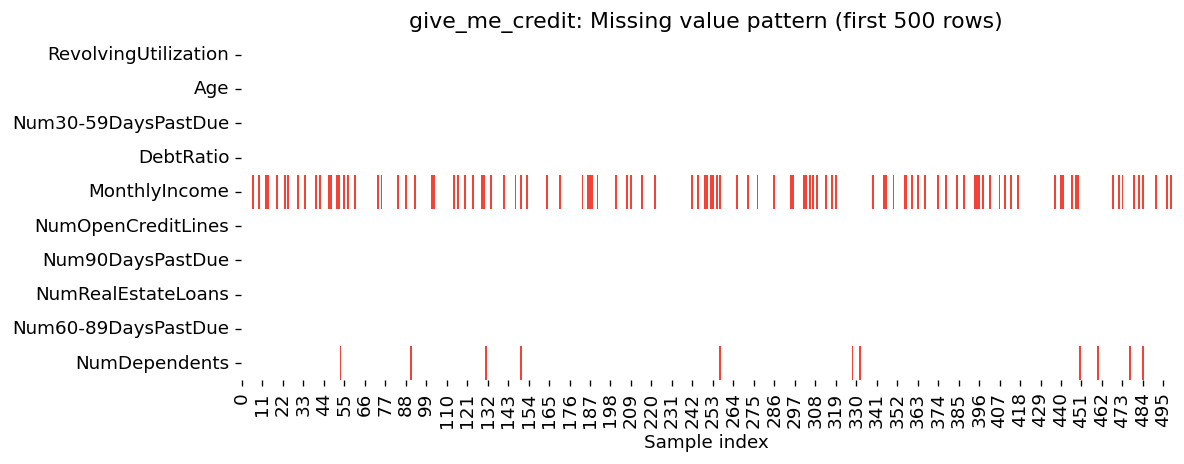

In [5]:
# Only show datasets with missing values
datasets_with_missing = [
    (name, X) for name, (X, y) in datasets.items() if X.isna().any().any()
]

if not datasets_with_missing:
    print('No missing values found in any dataset.')
else:
    for name, X in datasets_with_missing:
        missing_pct = (X.isna().sum() / len(X) * 100).sort_values(ascending=False)
        missing_pct = missing_pct[missing_pct > 0]
        print(f'\n{name} — columns with missing values:')
        print(missing_pct.to_string())
        
        # Sample-based heatmap (first 500 rows for readability)
        sample = X.head(500)
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.heatmap(sample.isna().T, cbar=False, ax=ax, 
                    cmap=['white', '#F44336'], linewidths=0)
        ax.set_title(f'{name}: Missing value pattern (first 500 rows)')
        ax.set_xlabel('Sample index')
        plt.tight_layout()
        plt.show()

## 5. Feature Distributions by Target Class

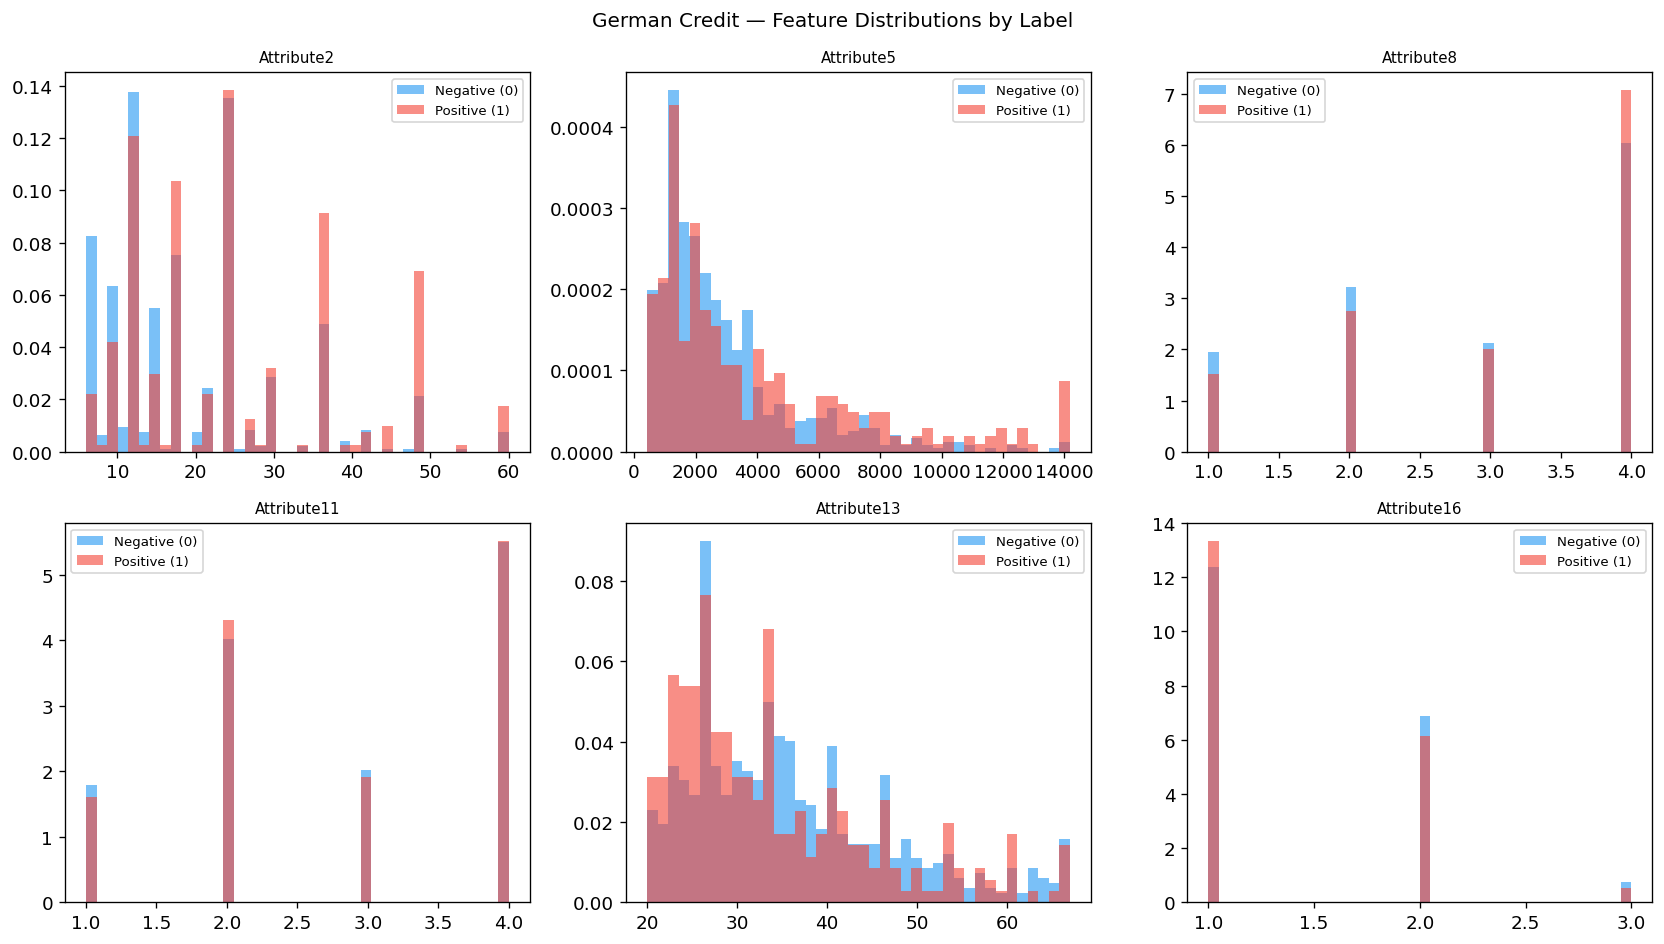

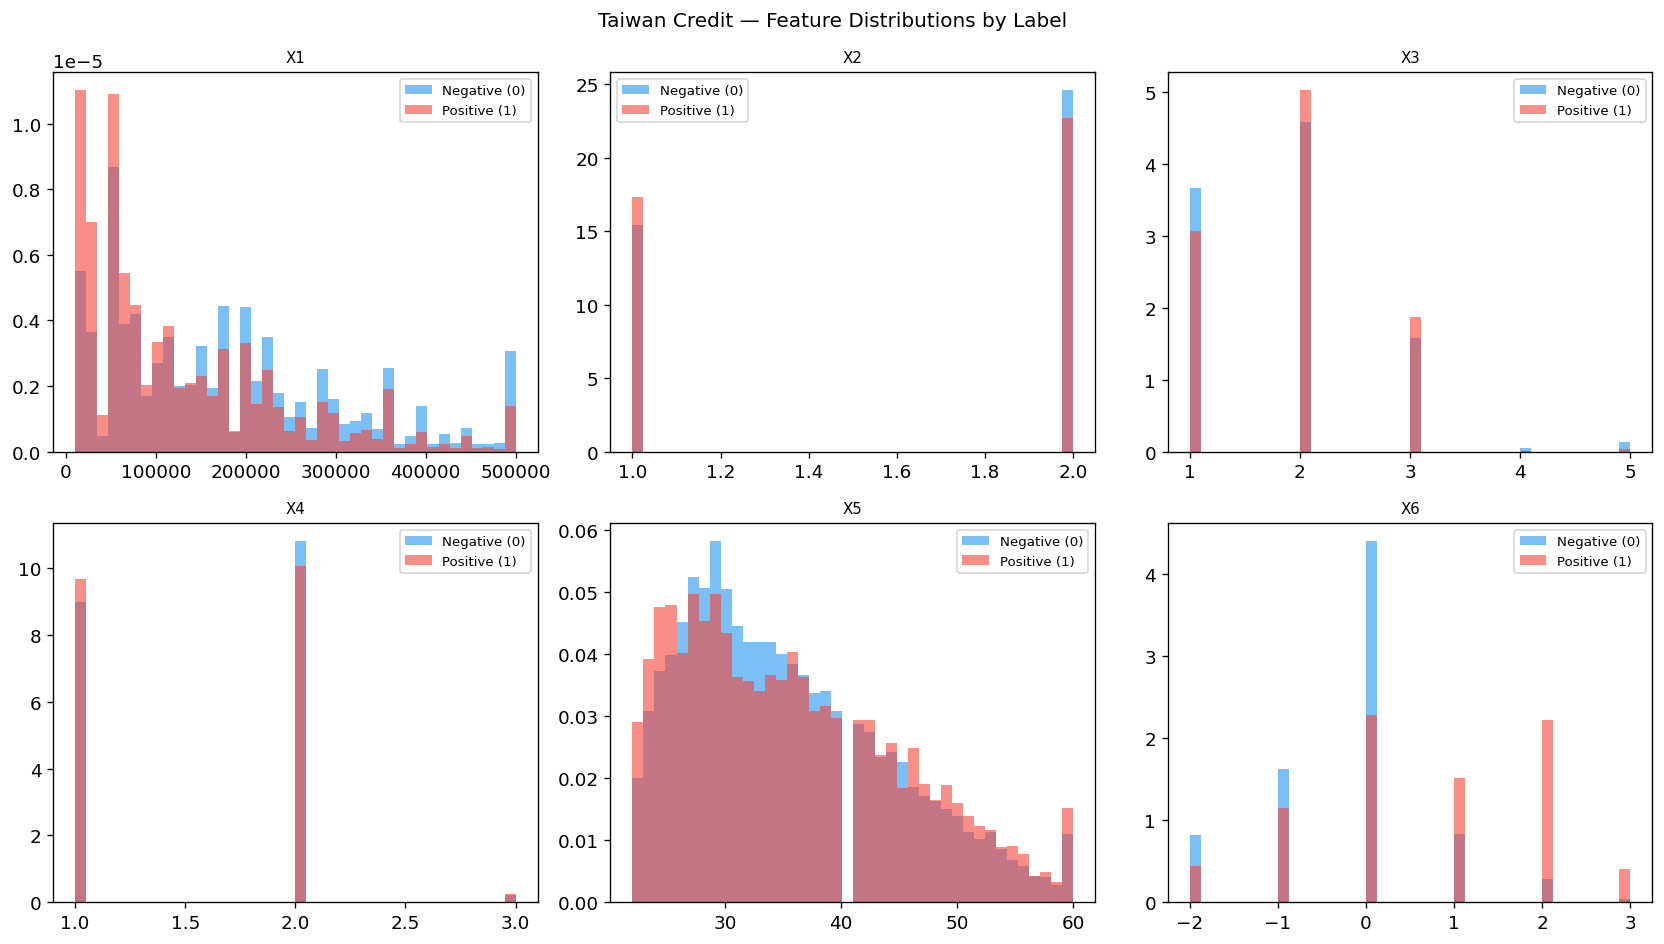

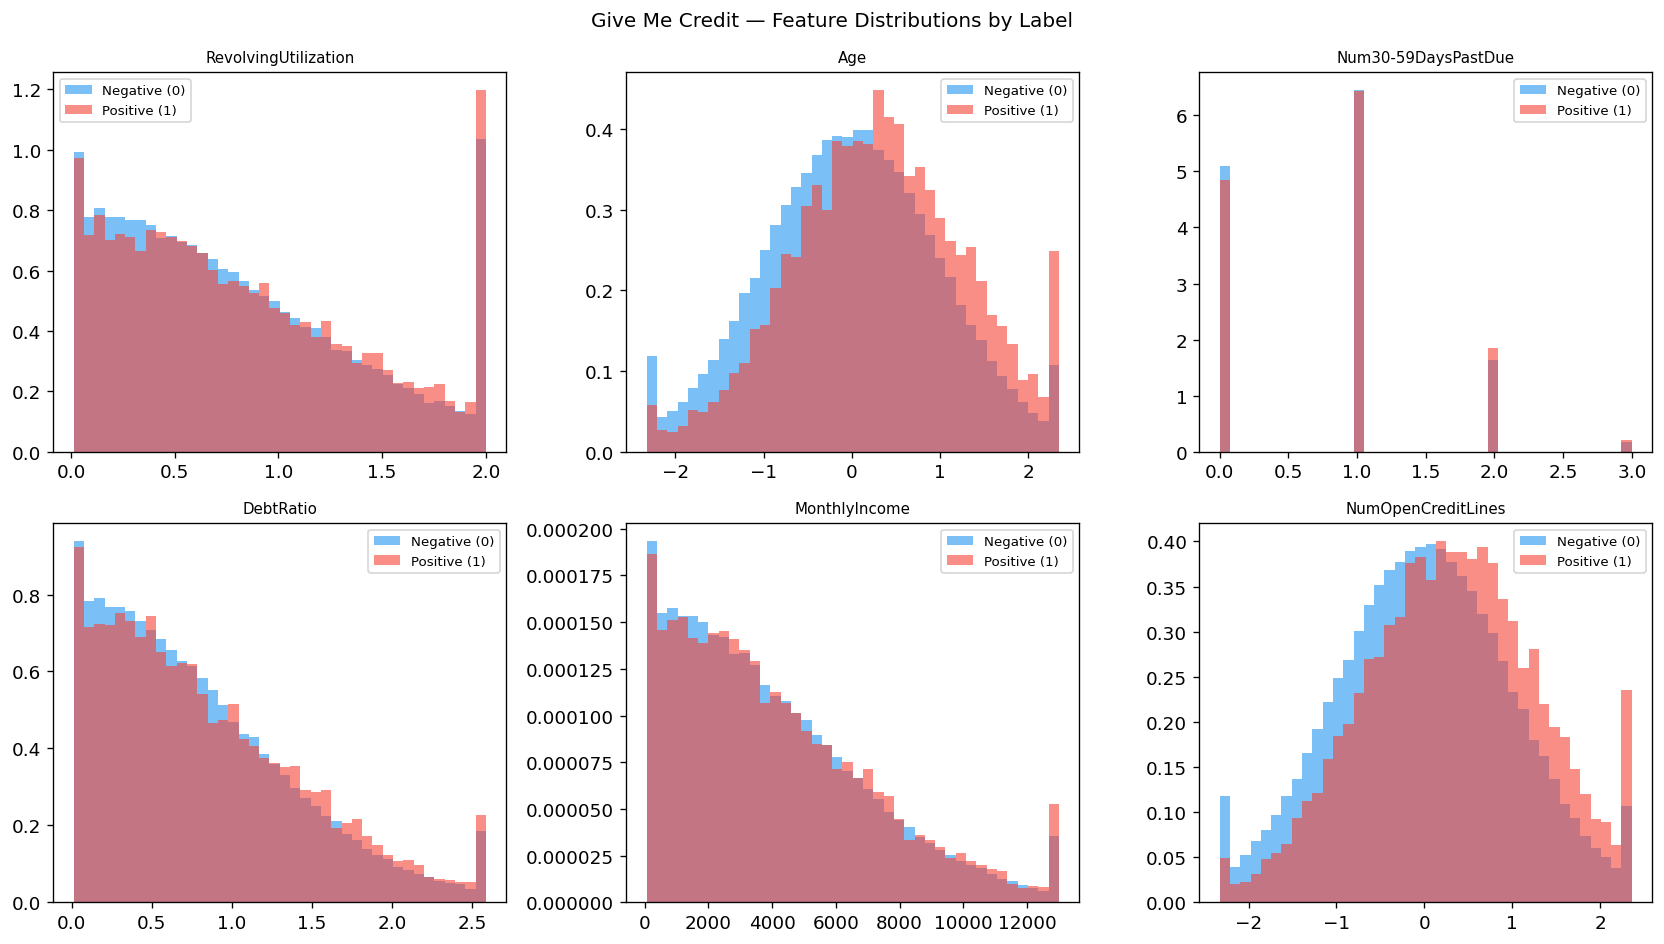

In [6]:
def plot_feature_distributions(X, y, n_features=6, title=''):
    num_cols = X.select_dtypes(include='number').columns[:n_features]
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    
    for i, col in enumerate(num_cols):
        ax = axes[i]
        X_neg = X.loc[y == 0, col].dropna()
        X_pos = X.loc[y == 1, col].dropna()
        
        # Clip extreme outliers for readability
        p1, p99 = X[col].quantile([0.01, 0.99])
        X_neg = X_neg.clip(p1, p99)
        X_pos = X_pos.clip(p1, p99)
        
        ax.hist(X_neg, bins=40, alpha=0.6, color='#2196F3', label='Negative (0)', density=True)
        ax.hist(X_pos, bins=40, alpha=0.6, color='#F44336', label='Positive (1)', density=True)
        ax.set_title(col[:25], fontsize=9)
        ax.legend(fontsize=8)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(f'{title} — Feature Distributions by Label', fontsize=12)
    plt.tight_layout()
    plt.show()


for name in dataset_names:
    X, y = datasets[name]
    plot_feature_distributions(X, y, title=name.replace('_', ' ').title())

## 6. Feature Correlation Matrix

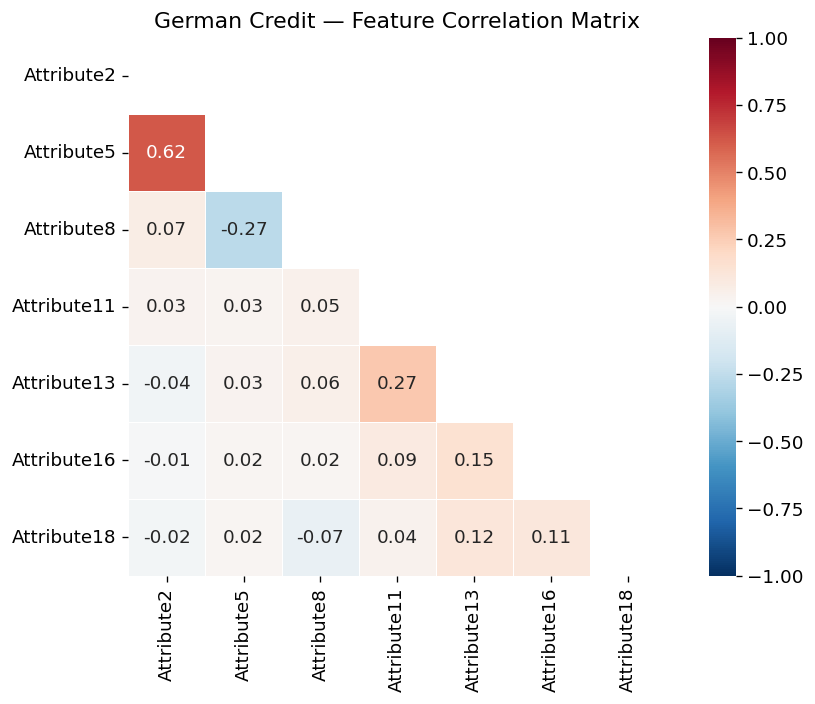

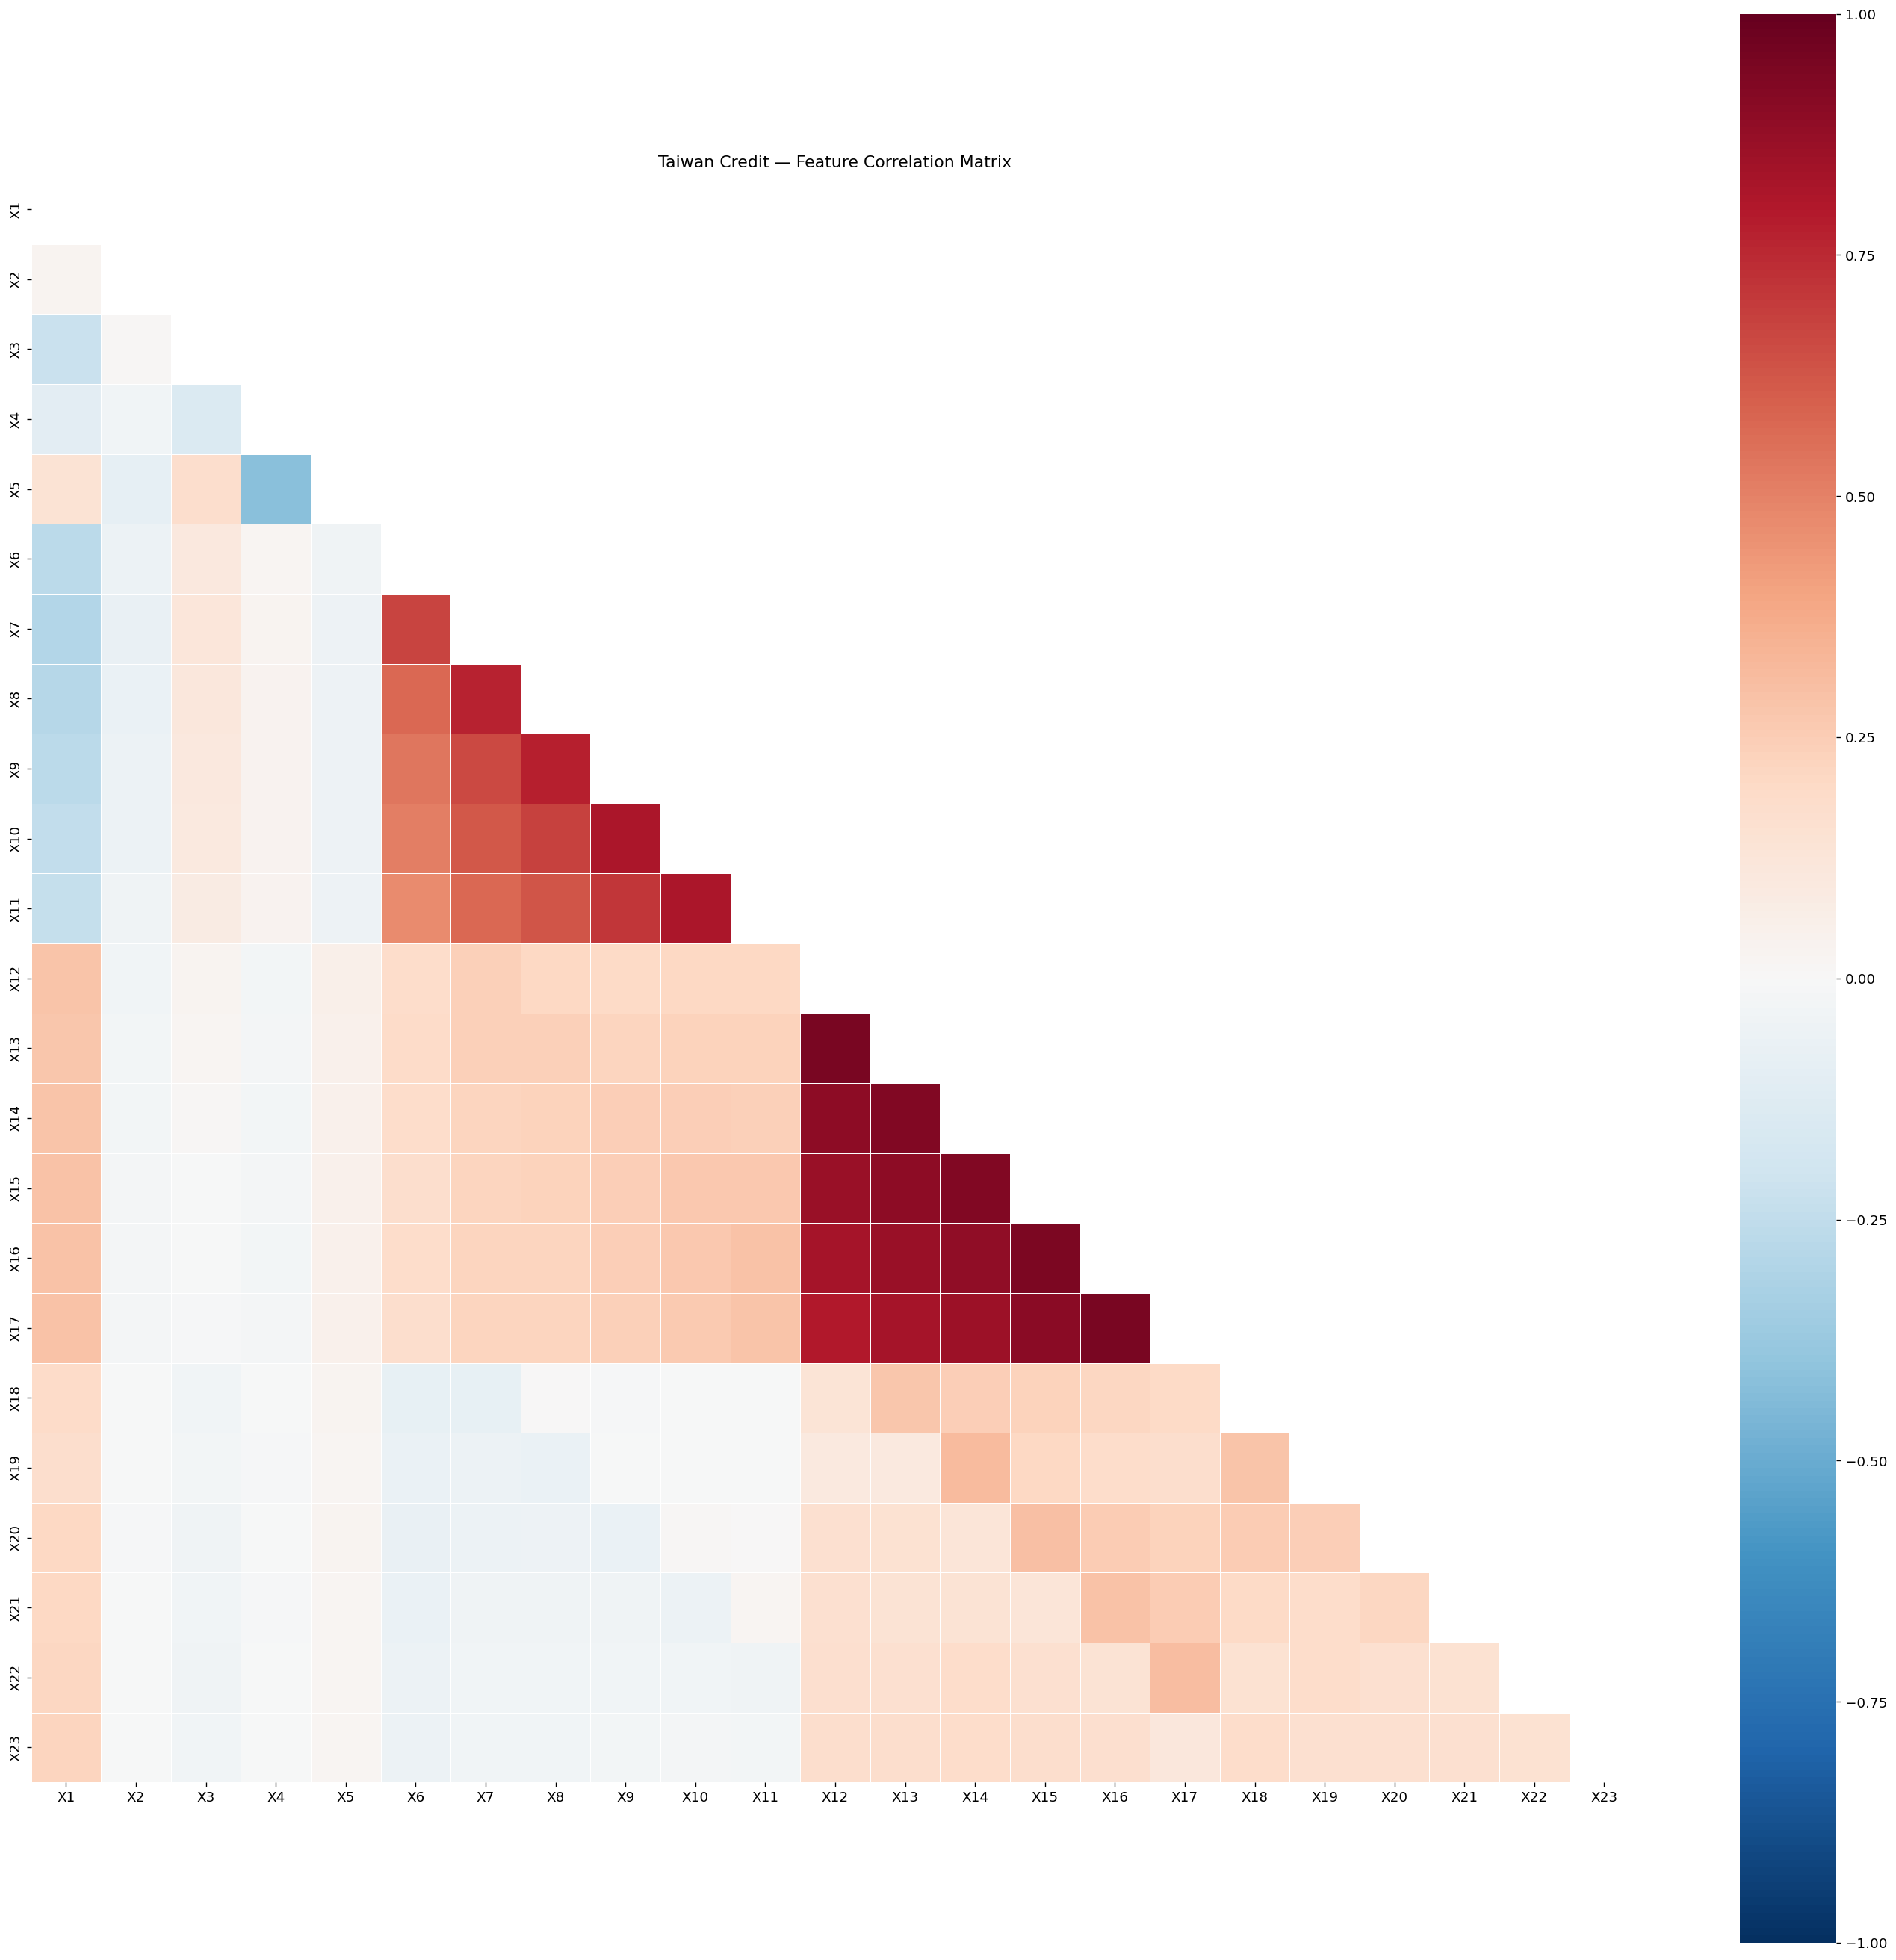

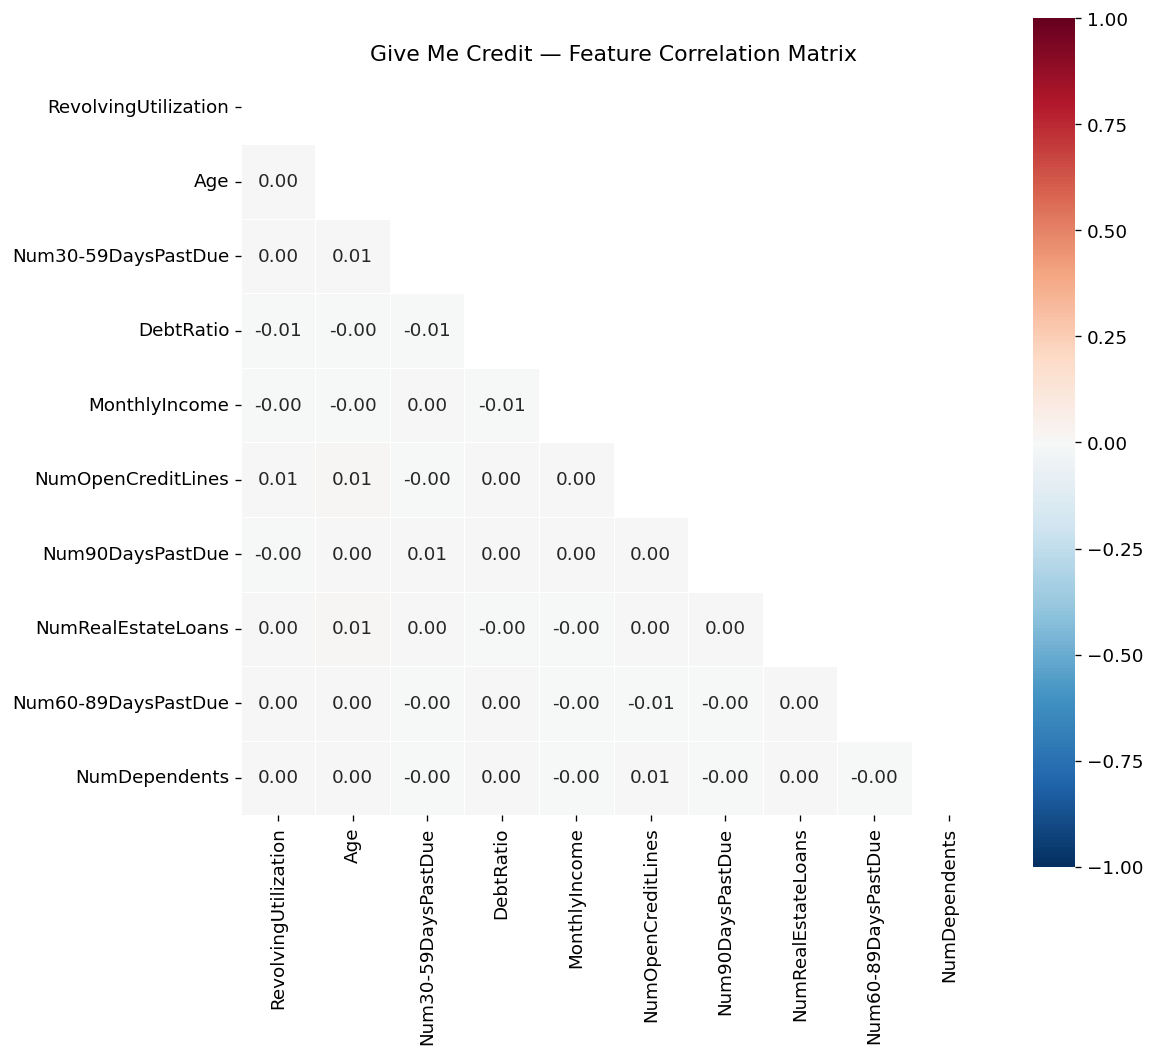

In [7]:
for name in dataset_names:
    X, y = datasets[name]
    num_cols = X.select_dtypes(include='number').columns
    corr = X[num_cols].corr()
    
    fig, ax = plt.subplots(figsize=(max(8, len(num_cols)), max(6, len(num_cols) - 1)))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=len(num_cols) <= 12, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=ax, square=True, linewidths=0.5)
    ax.set_title(f'{name.replace("_", " ").title()} — Feature Correlation Matrix')
    plt.tight_layout()
    plt.savefig(f'../results/figures/01_correlation_{name}.png', bbox_inches='tight')
    plt.show()

## 7. Export Summary Statistics

In [8]:
from pathlib import Path
results_dir = Path('../results')
results_dir.mkdir(exist_ok=True)

summary_rows = []
for name in dataset_names:
    X, y = datasets[name]
    info = get_dataset_info(name)
    summary_rows.append({
        'dataset': name,
        'n_samples': len(X),
        'n_features': X.shape[1],
        'n_numeric': X.select_dtypes(include='number').shape[1],
        'n_categorical': X.select_dtypes(include=['object','category']).shape[1],
        'positive_rate': y.mean(),
        'n_positive': y.sum(),
        'n_missing': X.isna().sum().sum(),
        'missing_rate': X.isna().mean().mean(),
        'source': info.get('source', 'N/A'),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(results_dir / 'dataset_summary.csv', index=False)
print('Saved results/dataset_summary.csv')
summary_df

Saved results/dataset_summary.csv


,dataset,n_samples,n_features,n_numeric,n_categorical,positive_rate,n_positive,n_missing,missing_rate,source
0,german_credit,1000,20,7,13,0.300000,300,0,0.000000,UCI
1,taiwan_credit,30000,23,23,0,0.221200,6636,0,0.000000,UCI
2,give_me_credit,150000,10,10,0,0.069187,10378,33848,0.022565,Kaggle


In [1]:
from tabpfn import TabPFNClassifier

ModuleNotFoundError: No module named 'tabpfn'

In [2]:
!pip3 install tabpfn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
from tabpfn import TabPFNClassifier

ModuleNotFoundError: No module named 'tabpfn'